In [2]:
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import logging
import os
import sys
import traceback
import yaml
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

In [3]:
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop5/adata_500k_residual.h5ad")

In [3]:
adata_ery = adata[adata.obs.experiment_number.isin(["264", "265", "266"])]

In [4]:
adata_ery

View of AnnData object with n_obs × n_vars = 75000 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'leiden', 'leiden_colors', 'meta', 'neighbors

## Check comparison CD41a 

In [5]:
cd235a_df = {"CD235a": adata_ery[:,"CD235a"].X.toarray().ravel(), 
             "experiment_number": adata_ery.obs["experiment_number"].values}

In [6]:
cd235a_df = pd.DataFrame(cd235a_df)

<Axes: xlabel='experiment_number', ylabel='CD235a'>

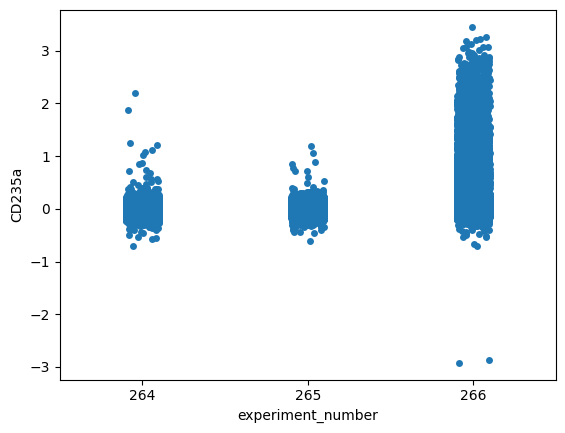

In [7]:
sns.stripplot(cd235a_df, x="experiment_number", y="CD235a")

# Classification 

In [8]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [9]:
# Standardization parameters 
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

adata_ery.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_ery.obs.columns
]

In [10]:
X_channel = adata_ery.X
X_channel = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter = []

for col in config.annotation.scatter_columns:
    col_vals = adata_ery.obs[col].astype(float).values
    X_scatter.append(col_vals)
    
X_scatter = np.stack(X_scatter, axis=1)
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]

X = np.concatenate(
    (
        X_channel, X_scatter
    ), axis=1
)

print(f"{X_channel.shape=} {X_scatter.shape=}")

X_channel.shape=(75000, 20) X_scatter.shape=(75000, 6)


In [11]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())
ct_predictions = np.concatenate(ct_predictions)

100%|██████████| 19/19 [00:04<00:00,  4.14it/s]


In [12]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [13]:
ct_predictions_str = classes[ct_predictions]
adata_ery.obs["cell_type"] = ct_predictions_str

/tmp/ipykernel_545843/2437882199.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ery.obs["cell_type"] = ct_predictions_str


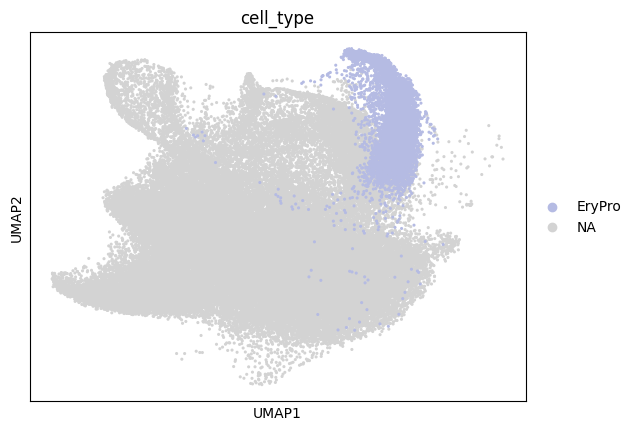

In [14]:
sc.pl.umap(adata_ery, color="cell_type", s=20, groups="EryPro")

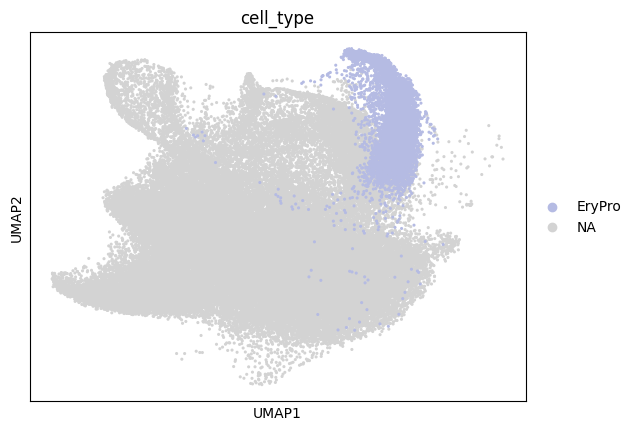

In [15]:
sc.pl.umap(adata_ery, color="cell_type", s=20, groups="EryPro")

## Plot cell type props

In [35]:
props_per_exp = {"Exp": [], 
                "prop_ery": [], 
                "prop_ery_lin": [], 
                "mean_cd235":[]}
for exp in ["264", "265", "266"]:
    adata_ery_exp = adata_ery[adata_ery.obs["experiment_number"]==exp]
    props = adata_ery_exp.obs.cell_type.value_counts()
    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0
    props = props / props.sum()
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_ery"].append(props["EryPro"])
    props_per_exp["prop_ery_lin"].append(props["EryPro"]+props["MgKEryPro1"]+props["MgKEryPro2"])
    cd235_vals = adata_ery_exp[:, "CD235a"].X.toarray().ravel()
    top25_thresh = np.quantile(cd235_vals, 0.75)
    props_per_exp["mean_cd235"].append(cd235_vals[cd235_vals >= top25_thresh].mean())

In [36]:
props_per_exp_df = pd.DataFrame(props_per_exp)

<Axes: xlabel='Exp', ylabel='prop_ery_lin'>

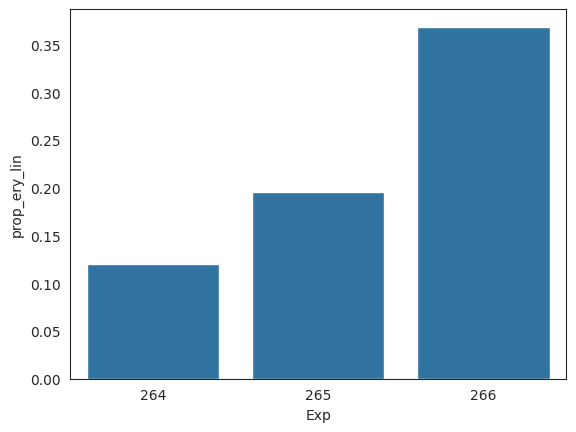

In [37]:
sns.barplot(props_per_exp_df, x="Exp", y="prop_ery_lin")

<Axes: xlabel='Exp', ylabel='prop_ery'>

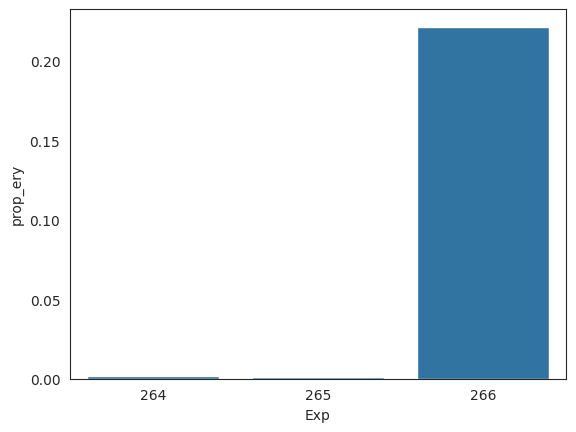

In [38]:
sns.barplot(props_per_exp_df, x="Exp", y="prop_ery")

## Compare to old data

In [39]:
adata_l1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")
adata_l2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_l2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")
adata_l3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/processed/adata_loop3_500k_residual_processed.h5ad")

In [40]:
adata_concat = sc.concat([adata_l1, adata_l2, adata_l2p5, adata_l3]) 

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [41]:
adata_concat.obs["experiment_number"] = adata_concat.obs["experiment_number"].astype(str)

In [42]:
for exp in np.unique(adata_concat.obs.experiment_number):
    adata_erypro_exp = adata_concat[adata_concat.obs["experiment_number"]==exp]
    props = adata_erypro_exp.obs.cell_type.value_counts()
    props = props / props.sum()
    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0
            
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_ery"].append(props["EryPro"])
    props_per_exp["prop_ery_lin"].append(props["EryPro"]+props["MgKEryPro1"]+props["MgKEryPro2"])
    cd235_vals = adata_erypro_exp[:, "CD235a"].X.toarray().ravel()
    top25_thresh = np.quantile(cd235_vals, 0.75)
    props_per_exp["mean_cd235"].append(cd235_vals[cd235_vals >= top25_thresh].mean())

In [43]:
props_per_exp = pd.DataFrame(props_per_exp)

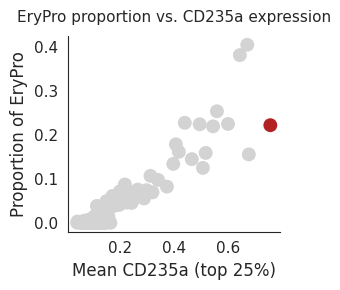

In [51]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(3, 3))

highlight = [ "266"]
is_highlight = props_per_exp["Exp"].isin(highlight)

# background points first
sns.scatterplot(
    data=props_per_exp[~is_highlight],
    x="mean_cd235",
    y="prop_ery",
    s=100,
    edgecolor="none",
    color="lightgray",
    ax=ax,
)

# highlighted points on top
sns.scatterplot(
    data=props_per_exp[is_highlight],
    x="mean_cd235",
    y="prop_ery",
    s=100,
    edgecolor="none",
    color="firebrick",
    ax=ax,
)

ax.set_xlabel("Mean CD235a (top 25%)", fontsize=12)
ax.set_ylabel("Proportion of EryPro", fontsize=12)
ax.set_title("EryPro proportion vs. CD235a expression", fontsize=11, pad=10)
ax.tick_params(axis="both", labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("erypro_scatter.png", dpi=300, bbox_inches="tight")
plt.show()